# Siren Exploration

This is a colab to explore properties of the Siren MLP, proposed in the work [Implicit Neural Activations with Periodic Activation Functions](https://vsitzmann.github.io/siren). Here, I am applying it to an MRI 4D flow dataset in a human aorta.


We will first implement a streamlined version of Siren for fast experimentation. This lacks the code to easily do baseline comparisons - please refer to the main code for that - but will greatly simplify the code!

Let's go! First, some imports, and a function to quickly generate coordinate grids.

In [163]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import os

from PIL import Image
from torchvision.transforms import Resize, Compose, ToTensor, Normalize
import numpy as np
import skimage
import matplotlib.pyplot as plt

import time

# JBM dependencies for our data: 
import h5py

def get_mgrid(sidelen, dim=2):
    '''Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    sidelen: int
    dim: int'''
    tensors = tuple(dim * [torch.linspace(-1, 1, steps=sidelen)])
    mgrid = torch.stack(torch.meshgrid(*tensors), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

# JBM: the following is an adaptation of the mgrid function to create coordinate grids for 
# unevenly dimensioned datasets. We need this for aorta data (usually a long rectangle!)
def get_mgrid_arbstep(sidelen_x, sidelen_y, sidelen_z, dim=3):
    '''Generates a flattened grid of (x,y,...) coordinates in a range of -1 to 1.
    Allows for different number of samples along different axes. 
    sidelen: int
    dim: int'''
    tensorx = torch.linspace(-1, 1, steps=sidelen_x)
    tensory = torch.linspace(-1, 1, steps=sidelen_y)
    tensorz = torch.linspace(-1, 1, steps=sidelen_z)

    mgrid = torch.stack(torch.meshgrid([tensorx, tensory, tensorz]), dim=-1)
    mgrid = mgrid.reshape(-1, dim)
    return mgrid

In [164]:
# This cell is just to test my arbstep mgrid
mgrid = get_mgrid(100,dim=3)
mgrid = get_mgrid_arbstep(100,100,100,dim=3)

Now, we code up the sine layer, which will be the basic building block of SIREN. This is a much more concise implementation than the one in the main code, as here, we aren't concerned with the baseline comparisons.

In [165]:
class SineLayer(nn.Module):
    # See paper sec. 3.2, final paragraph, and supplement Sec. 1.5 for discussion of omega_0.
    
    # If is_first=True, omega_0 is a frequency factor which simply multiplies the activations before the 
    # nonlinearity. Different signals may require different omega_0 in the first layer - this is a 
    # hyperparameter.
    
    # If is_first=False, then the weights will be divided by omega_0 so as to keep the magnitude of 
    # activations constant, but boost gradients to the weight matrix (see supplement Sec. 1.5)
    
    def __init__(self, in_features, out_features, bias=True,
                 is_first=False, omega_0=30):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        
        self.in_features = in_features
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        
        self.init_weights()
    
    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features, 
                                             1 / self.in_features)      
            else:
                self.linear.weight.uniform_(-np.sqrt(6 / self.in_features) / self.omega_0, 
                                             np.sqrt(6 / self.in_features) / self.omega_0)
        
    def forward(self, input):
        return torch.sin(self.omega_0 * self.linear(input))
    
    def forward_with_intermediate(self, input): 
        # For visualization of activation distributions
        intermediate = self.omega_0 * self.linear(input)
        return torch.sin(intermediate), intermediate
    
    
class Siren(nn.Module):
    def __init__(self, in_features, hidden_features, hidden_layers, out_features, outermost_linear=False, 
                 first_omega_0=30, hidden_omega_0=30.):
        super().__init__()
        
        self.net = []
        self.net.append(SineLayer(in_features, hidden_features, 
                                  is_first=True, omega_0=first_omega_0))

        for i in range(hidden_layers):
            self.net.append(SineLayer(hidden_features, hidden_features, 
                                      is_first=False, omega_0=hidden_omega_0))

        if outermost_linear:
            final_linear = nn.Linear(hidden_features, out_features)
            
            with torch.no_grad():
                final_linear.weight.uniform_(-np.sqrt(6 / hidden_features) / hidden_omega_0, 
                                              np.sqrt(6 / hidden_features) / hidden_omega_0)
                
            self.net.append(final_linear)
        else:
            self.net.append(SineLayer(hidden_features, out_features, 
                                      is_first=False, omega_0=hidden_omega_0))
        
        self.net = nn.Sequential(*self.net)
    
    def forward(self, coords):
        coords = coords.clone().detach().requires_grad_(True) # allows to take derivative w.r.t. input
        output = self.net(coords)
        return output, coords        

    def forward_with_activations(self, coords, retain_grad=False):
        '''Returns not only model output, but also intermediate activations.
        Only used for visualizing activations later!'''
        activations = OrderedDict()

        activation_count = 0
        x = coords.clone().detach().requires_grad_(True)
        activations['input'] = x
        for i, layer in enumerate(self.net):
            if isinstance(layer, SineLayer):
                x, intermed = layer.forward_with_intermediate(x)
                
                if retain_grad:
                    x.retain_grad()
                    intermed.retain_grad()
                    
                activations['_'.join((str(layer.__class__), "%d" % activation_count))] = intermed
                activation_count += 1
            else: 
                x = layer(x)
                
                if retain_grad:
                    x.retain_grad()
                    
            activations['_'.join((str(layer.__class__), "%d" % activation_count))] = x
            activation_count += 1

        return activations

JBM: We're going to do another trick here: use a fourier feature transform. These are shown to quite drastically improve the performance of INR fitting, especially where high-frequency features are concerned. This was not used in the initial SIREN notebook

In [166]:
class GaussianFourierFeatureTransform(torch.nn.Module):
    """
    An implementation of Gaussian Fourier feature mapping.

    "Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains":
       https://arxiv.org/abs/2006.10739
       https://people.eecs.berkeley.edu/~bmild/fourfeat/index.html

    Given an input of size [batches, num_input_channels, width, height],
     returns a tensor of size [batches, mapping_size*2, width, height].
    """

    def __init__(self, num_input_channels, mapping_size=256, scale=10):
        super().__init__()

        self._num_input_channels = num_input_channels
        self._mapping_size = mapping_size
        self._B = torch.randn((num_input_channels, mapping_size)) * scale

    def forward(self, x):

        x = x @ self._B.to(x.device)

        x = 2 * np.pi * x
        return torch.cat([torch.sin(x), torch.cos(x)], dim=2)

<a id='section_1'></a>
## Fitting a 4D flow dataset

First, let's simply fit a static (no time dimension) dataset!

We seek to parameterize a velocity vector field $f(x)$ with voxel coordinates $x$ with a SIREN $\Phi(x)$.

That is we seek the function $\Phi$ such that:
$\mathcal{L}=\int_{\Omega} \lVert \Phi(\mathbf{x}) - f(\mathbf{x}) \rVert\mathrm{d}\mathbf{x}$
 is minimized, in which $\Omega$ is the domain of the 4D flow dataset. 
 
We write a little datast that does nothing except calculating per-pixel coordinates, and gets our pixel values (velocity) properly structured:

In [167]:
class FlowFitting(Dataset):
    def __init__(self, sidelength_x, sidelength_y, sidelength_z, u, v, w, t):
        super().__init__()
        # img = get_cameraman_tensor(sidelength)
        # self.pixels = img.permute(1, 2, 0).view(-1, 1)

        u = u[t,:,:,:].flatten()
        v = v[t,:,:,:].flatten()
        w = w[t,:,:,:].flatten()

        # self.pixels = torch.cat((u[:,None], v[:,None], w[:,None]), dim=1)
        self.pixels = torch.stack((u, v, w),dim=-1)
        
        self.coords = get_mgrid_arbstep(sidelength_x, sidelength_y, sidelength_z)

        nonzeros = self.pixels != 0
        self.mask = self.pixels.masked_fill(~nonzeros,0)
        self.mask = self.pixels.masked_fill(nonzeros,1)

        print("Coord shape = ", np.shape(self.coords))
        print("Flow v ('pixels') output shape = ", np.shape(self.pixels))
        print("Mask shape = ", np.shape(self.mask))

    def __len__(self):
        return 1

    def __getitem__(self, idx):    
        if idx > 0: raise IndexError
            
        return self.coords, self.pixels

Before actually getting it in dataset format, do some loading and processing of the .h5 4D flow data. I'd like to combine this with the class above in the future, but for now it is totally fine to run with the following: 

Keys: <KeysViewHDF5 ['SNRdb', 'mag_u', 'mag_v', 'mag_w', 'mask', 'u', 'v', 'venc_u', 'venc_v', 'venc_w', 'w']>
<class 'h5py._hl.dataset.Dataset'>


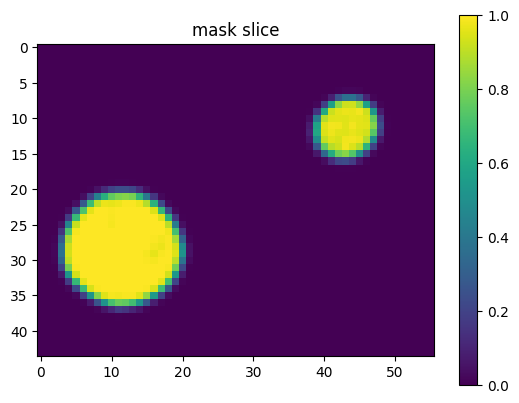

Shape of u =  torch.Size([71, 164, 44, 56])


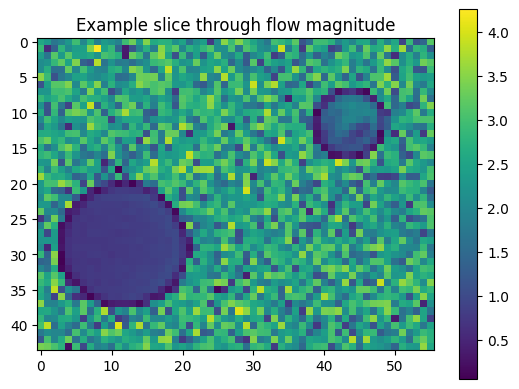

In [168]:
# JBM Load the (LR) data via h5py
filename = "data/aorta03trans_LR.h5"
with h5py.File(filename, "r") as f:
    # Print all root level object names (aka keys) 
    # these can be group or dataset names 
    print("Keys: %s" % f.keys())
    
    # get first object name/key; may or may NOT be a group
    a_group_key = list(f.keys())[0]

    # get the object type for a_group_key: usually group or dataset
    print(type(f[a_group_key])) 

    # If a_group_key is a group name, 
    # this gets the object names in the group and returns as a list
    data = list(f[a_group_key])

    # If a_group_key is a dataset name, 
    # this gets the dataset values and returns as a list
    data = list(f[a_group_key])
    # preferred methods to get dataset values:
    ds_obj = f[a_group_key]      # returns as a h5py dataset object
    u_np = f['u'][()]  # returns as a numpy array
    v_np = f['v'][()]  # returns as a numpy array
    w_np = f['w'][()]  # returns as a numpy array
    mask_np = f['mask'][()]
    plt.imshow(np.squeeze(mask_np[:,41,:,:]))
    plt.title('mask slice')
    plt.colorbar()
    plt.show()
    mask_all_slice = torch.from_numpy(np.repeat(mask_np,71,axis=0))

     
    # convert all to tensor
    u = torch.from_numpy(u_np)
    v = torch.from_numpy(v_np)
    w = torch.from_numpy(w_np)

    # normalize to [-1,1] 
    max_vel = torch.max(torch.tensor([torch.max(u),torch.max(v),torch.max(w)]))
    u = u/max_vel
    v = v/max_vel
    w = w/max_vel

    mask_velocities = True
    if mask_velocities:
        u = u * mask_all_slice
        v = v * mask_all_slice
        w = w * mask_all_slice
    
    # Coords: [T, X, Y, Z]
    print('Shape of u = ', np.shape(u))
    plt.imshow(np.sqrt(u_np[15,41,:,:]**2 + v_np[15,41,:,:]**2 + w_np[15,41,:,:]**2))
    plt.title('Example slice through flow magnitude')
    plt.colorbar()
    plt.show()


Let's instantiate the dataset and our Siren. As pixel coordinates are 3D, the feature transformer has 3 input features, and since the 4D flow data is a 3D vector, the output size has 3 features. Since the flow is input -> transformer -> network, the network takes in the size of the fourier features

In [175]:
flowd = FlowFitting(164,44,56, u, v, w, t=15)
dataloader = DataLoader(flowd, batch_size=1, pin_memory=True, num_workers=0)

num_fourier_features = 256
feature_transformer = GaussianFourierFeatureTransform(num_input_channels=3,
                                                      mapping_size=num_fourier_features, scale=5)

# Initial experiment with just XYZ, no T coordinate. Outputs UVW
img_siren = Siren(in_features=2*num_fourier_features, out_features=3, hidden_features=256, 
                  hidden_layers=3, outermost_linear=True)

# TODO(JBM): need to provide option to use CUDA if GPU AVAILABLE. This currently just runs on CPU, wh
#img_siren.cuda()

Coord shape =  torch.Size([404096, 3])
Flow v ('pixels') output shape =  torch.Size([404096, 3])
Mask shape =  torch.Size([404096, 3])


We now fit Siren in a simple training loop. Within only hundreds of iterations, the 4D flow dataset (at one timepoint) is approximated well. Note - this is an unoptimized Siren! You can definitely get much better performance if you think a little harder about architecture, hyperparameters, etc. 

In [176]:
total_steps = 200 # Since the whole image is our dataset, this just means 500 gradient descent steps.
steps_til_summary = 10

optim = torch.optim.Adam(lr=1e-4, weight_decay=1e-3, params=img_siren.parameters())

model_input, ground_truth = next(iter(dataloader))
model_input = feature_transformer(model_input)

# TODO(JBM): need to provide option to use CUDA if GPU AVAILABLE
#model_input, ground_truth = model_input.cuda(), ground_truth.cuda()

for step in range(total_steps):
    model_output, coords = img_siren(model_input)    
    #loss = ((mask*(model_output - ground_truth)**2)).mean()
    # JBM: only considering loss inside the vessels. Thus will get junk outside of aorta, but don't really care! 
    loss = ((flowd.mask*(model_output - ground_truth)**2)).mean()

    if not step % steps_til_summary:
        print("Step %d, Total loss %0.6f" % (step, loss))

    optim.zero_grad()
    loss.backward()
    optim.step()

Step 0, Total loss 0.001756


KeyboardInterrupt: 

tensor([[-1.0000, -1.0000],
        [-1.0000, -0.9866],
        [-1.0000, -0.9732],
        ...,
        [ 1.0000,  0.9732],
        [ 1.0000,  0.9866],
        [ 1.0000,  1.0000]])
torch.Size([1, 22500, 3])


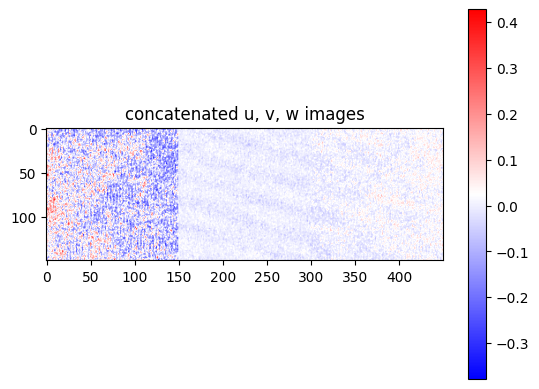

In [173]:
# print(np.shape(model_output))
# model_output_reshape = model_output[:,:,1].cpu().view(164,44,56).detach().numpy()
# plt.imshow(model_output_reshape[:,20,:])
# plt.colorbar()
# plt.show()

eval_dim = 150
mgrid = get_mgrid(eval_dim)
print(mgrid)
zgrid = torch.ones((eval_dim*eval_dim,1))*0
mgrid = torch.cat((mgrid,zgrid),1)
mgrid = mgrid[None,:,:]

model_output_slice, coords = img_siren(feature_transformer(mgrid))
print(np.shape(model_output_slice))
model_output_slice_u = model_output_slice[:,:,0]
model_output_slice_v = model_output_slice[:,:,1]
model_output_slice_w = model_output_slice[:,:,2]

u_img = model_output_slice_u.cpu().view(eval_dim,eval_dim).detach().numpy()
v_img = model_output_slice_v.cpu().view(eval_dim,eval_dim).detach().numpy()
w_img = model_output_slice_w.cpu().view(eval_dim,eval_dim).detach().numpy()

plt.imshow(np.concatenate((u_img,v_img,w_img),axis=1), cmap='bwr')
plt.title('concatenated u, v, w images')
plt.colorbar()
plt.show()

In [174]:
# OK, let's now make a gif through this dataset at this time 
tgrid = np.linspace(-1,1,100)
images = []

for i in range(tgrid.shape[0]):
    # Access each slice (2D array)
    mgrid = get_mgrid(eval_dim)
    zgrid = torch.ones((eval_dim*eval_dim,1))*tgrid[i]
    mgrid = torch.cat((mgrid,zgrid),1)
    mgrid = mgrid[None,:,:]

    model_output_slice, coords = img_siren(feature_transformer(mgrid))
    model_output_slice_u = model_output_slice[:,:,0]
    model_output_slice_v = model_output_slice[:,:,1]
    model_output_slice_w = model_output_slice[:,:,2]
    
    u_img = model_output_slice_u.cpu().view(eval_dim,eval_dim).detach().numpy()
    v_img = model_output_slice_v.cpu().view(eval_dim,eval_dim).detach().numpy()
    w_img = model_output_slice_w.cpu().view(eval_dim,eval_dim).detach().numpy()

    all_img = np.concatenate((u_img,v_img,w_img),axis=1)
    
    # Plot the slice using matplotlib
    plt.imshow(all_img, cmap='gray', interpolation='none')
    plt.title('concatenated [u, v, w]')
    plt.axis('off')

    # Save the plot to a PNG file
    plt.savefig(f'out_images/slice_{i}.png', bbox_inches='tight', pad_inches=0)
    plt.close()

    # Open the PNG file and append it to the images list
    image = Image.open(f'out_images/slice_{i}.png')
    images.append(image)

# Create a GIF from the images
images[0].save(
    'out_images/output.gif',
    save_all=True,
    append_images=images[1:],
    duration=50,  # Duration between frames in milliseconds
    loop=0  # Loop forever
)

print("GIF created successfully.")

GIF created successfully.


<a id='out_of_range'></a>
## Case study: Siren periodicity & out-of-range behavior

It is known that the sum of two periodic signals is itself periodic with a period that is equal to the least common multiple of the periods of the two summands, if and only if the two periods are rational multiples of each other. If the ratio of the two periods is irrational, then their sum will *not* be periodic itself.

Due to the floating-point representation in neural network libraries, this case cannot occur in practice, and all functions parameterized by Siren indeed have to be periodic.

Yet, the period of the resulting function may in practice be several orders of magnitudes larger than the period of each Siren neuron!

Let's test this with two sines.

In [ ]:
with torch.no_grad():
    coords = get_mgrid(2**10, 1) * 5 * np.pi
    
    sin_1 = torch.sin(coords)
    sin_2 = torch.sin(coords * 2)
    sum = sin_1 + sin_2
    
    fig, ax = plt.subplots(figsize=(16,2))
    ax.plot(coords, sum)
    ax.plot(coords, sin_1)
    ax.plot(coords, sin_2)
    plt.title("Rational multiple")
    plt.show()
    
    sin_1 = torch.sin(coords)
    sin_2 = torch.sin(coords * np.pi)
    sum = sin_1 + sin_2
    
    fig, ax = plt.subplots(figsize=(16,2))
    ax.plot(coords, sum)
    ax.plot(coords, sin_1)
    ax.plot(coords, sin_2)
    plt.title("Pseudo-irrational multiple")
    plt.show()

Though the second plot looks periodic, closer inspection shows that the period of the blue line is indeed larger than the range we're sampling here. 

Let's take a look at what the Siren we just trained looks like outside its training domain!

In [ ]:
with torch.no_grad():
    out_of_range_coords = get_mgrid(1024, 2) * 50
    model_out, _ = img_siren(out_of_range_coords.cuda())
    
    fig, ax = plt.subplots(figsize=(16,16))
    ax.imshow(model_out.cpu().view(1024,1024).numpy())
    plt.show()

Though there is some self-similarity, the signal is not repeated on this range of (-50, 50).

## Fitting an audio signal
<a id='section_2'></a>

Here, we'll use Siren to parameterize an audio signal - i.e., we seek to parameterize an audio waverform $f(t)$  at time points $t$ by a SIREN $\Phi$.

That is we seek the function $\Phi$ such that:  $\mathcal{L}\int_\Omega \lVert \Phi(t) - f(t) \rVert \mathrm{d}t$  is minimized, in which  $\Omega$  is the domain of the waveform.

For the audio, we'll use the bach sonata:

In [ ]:
import scipy.io.wavfile as wavfile
import io
from IPython.display import Audio

if not os.path.exists('gt_bach.wav'):
    !wget https://vsitzmann.github.io/siren/img/audio/gt_bach.wav

Let's build a little dataset that computes coordinates for audio files:

In [ ]:
class AudioFile(torch.utils.data.Dataset):
    def __init__(self, filename):
        self.rate, self.data = wavfile.read(filename)
        self.data = self.data.astype(np.float32)
        self.timepoints = get_mgrid(len(self.data), 1)

    def get_num_samples(self):
        return self.timepoints.shape[0]

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        amplitude = self.data
        scale = np.max(np.abs(amplitude))
        amplitude = (amplitude / scale)
        amplitude = torch.Tensor(amplitude).view(-1, 1)
        return self.timepoints, amplitude

Let's instantiate the Siren. As this audio signal has a much higer spatial frequency on the range of -1 to 1, we increase the $\omega_0$ in the first layer of siren.

In [ ]:
bach_audio = AudioFile('gt_bach.wav')

dataloader = DataLoader(bach_audio, shuffle=True, batch_size=1, pin_memory=True, num_workers=0)

# Note that we increase the frequency of the first layer to match the higher frequencies of the
# audio signal. Equivalently, we could also increase the range of the input coordinates.
audio_siren = Siren(in_features=1, out_features=1, hidden_features=256, 
                    hidden_layers=3, first_omega_0=3000, outermost_linear=True)
audio_siren.cuda()

Let's have a quick listen to ground truth:

In [ ]:
rate, _ = wavfile.read('gt_bach.wav')

model_input, ground_truth = next(iter(dataloader))
Audio(ground_truth.squeeze().numpy(),rate=rate)

We now fit the Siren to this signal.

In [ ]:
total_steps = 1000 
steps_til_summary = 100

optim = torch.optim.Adam(lr=1e-4, params=audio_siren.parameters())

model_input, ground_truth = next(iter(dataloader))
model_input, ground_truth = model_input.cuda(), ground_truth.cuda()

for step in range(total_steps):
    model_output, coords = audio_siren(model_input)    
    loss = F.mse_loss(model_output, ground_truth)
    
    if not step % steps_til_summary:
        print("Step %d, Total loss %0.6f" % (step, loss))
    
        fig, axes = plt.subplots(1,2)
        axes[0].plot(coords.squeeze().detach().cpu().numpy(),model_output.squeeze().detach().cpu().numpy())
        axes[1].plot(coords.squeeze().detach().cpu().numpy(),ground_truth.squeeze().detach().cpu().numpy())
        plt.show()

    optim.zero_grad()
    loss.backward()
    optim.step()

In [ ]:
final_model_output, coords = audio_siren(model_input)
Audio(final_model_output.cpu().detach().squeeze().numpy(),rate=rate)

As we can see, within few iterations, Siren has approximated the audio signal very well!

<a id='section_3'></a>
## Solving Poisson's equation

Now, let's make it a bit harder. Let's say we want to reconstruct an image but we only have access to its gradients!

That is, we now seek the function $\Phi$ such that:
$\mathcal{L}=\int_{\Omega} \lVert \nabla\Phi(\mathbf{x}) - \nabla f(\mathbf{x}) \rVert\mathrm{d}\mathbf{x}$
 is minimized, in which $\Omega$ is the domain of the image. 

In [ ]:
import scipy.ndimage
    
class PoissonEqn(Dataset):
    def __init__(self, sidelength):
        super().__init__()
        img = get_cameraman_tensor(sidelength)
        
        # Compute gradient and laplacian       
        grads_x = scipy.ndimage.sobel(img.numpy(), axis=1).squeeze(0)[..., None]
        grads_y = scipy.ndimage.sobel(img.numpy(), axis=2).squeeze(0)[..., None]
        grads_x, grads_y = torch.from_numpy(grads_x), torch.from_numpy(grads_y)
                
        self.grads = torch.stack((grads_x, grads_y), dim=-1).view(-1, 2)
        self.laplace = scipy.ndimage.laplace(img.numpy()).squeeze(0)[..., None]
        self.laplace = torch.from_numpy(self.laplace)
        
        self.pixels = img.permute(1, 2, 0).view(-1, 1)
        self.coords = get_mgrid(sidelength, 2)

    def __len__(self):
        return 1

    def __getitem__(self, idx):
        return self.coords, {'pixels':self.pixels, 'grads':self.grads, 'laplace':self.laplace}

#### Instantiate SIREN model

In [ ]:
cameraman_poisson = PoissonEqn(128)
dataloader = DataLoader(cameraman_poisson, batch_size=1, pin_memory=True, num_workers=0)

poisson_siren = Siren(in_features=2, out_features=1, hidden_features=256, 
                      hidden_layers=3, outermost_linear=True)
poisson_siren.cuda()

#### Define the loss function

In [ ]:
def gradients_mse(model_output, coords, gt_gradients):
    # compute gradients on the model
    gradients = gradient(model_output, coords)
    # compare them with the ground-truth
    gradients_loss = torch.mean((gradients - gt_gradients).pow(2).sum(-1))
    return gradients_loss

#### Train the model

In [ ]:
total_steps = 1000
steps_til_summary = 10

optim = torch.optim.Adam(lr=1e-4, params=poisson_siren.parameters())

model_input, gt = next(iter(dataloader))
gt = {key: value.cuda() for key, value in gt.items()}
model_input = model_input.cuda()

for step in range(total_steps):
    start_time = time.time()

    model_output, coords = poisson_siren(model_input)
    train_loss = gradients_mse(model_output, coords, gt['grads'])

    if not step % steps_til_summary:
        print("Step %d, Total loss %0.6f, iteration time %0.6f" % (step, train_loss, time.time() - start_time))

        img_grad = gradient(model_output, coords)
        img_laplacian = laplace(model_output, coords)

        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(model_output.cpu().view(128,128).detach().numpy())
        axes[1].imshow(img_grad.cpu().norm(dim=-1).view(128,128).detach().numpy())
        axes[2].imshow(img_laplacian.cpu().view(128,128).detach().numpy())
        plt.show()
        
    optim.zero_grad()
    train_loss.backward()
    optim.step()

<a id='activations'></a>
## Initialization scheme & distribution of activations

We now reproduce the empirical result on the distribution of activations, and will thereafter show empirically that the distribution of activations is shift-invariant as well! 

In [ ]:
from collections import OrderedDict
import matplotlib
import numpy.fft as fft
import scipy.stats as stats


def eformat(f, prec, exp_digits):
    s = "%.*e"%(prec, f)
    mantissa, exp = s.split('e')
    # add 1 to digits as 1 is taken by sign +/-
    return "%se%+0*d"%(mantissa, exp_digits+1, int(exp))

def format_x_ticks(x, pos):
    """Format odd tick positions
    """
    return eformat(x, 0, 1)

def format_y_ticks(x, pos):
    """Format odd tick positions
    """
    return eformat(x, 0, 1)

def get_spectrum(activations):
    n = activations.shape[0]

    spectrum = fft.fft(activations.numpy().astype(np.double).sum(axis=-1), axis=0)[:n//2]
    spectrum = np.abs(spectrum)

    max_freq = 100                
    freq = fft.fftfreq(n, 2./n)[:n//2]
    return freq[:max_freq], spectrum[:max_freq]


def plot_all_activations_and_grads(activations):
    num_cols = 4
    num_rows = len(activations)
    
    fig_width = 5.5
    fig_height = num_rows/num_cols*fig_width
    fig_height = 9
    
    fontsize = 5
        
    fig, axs = plt.subplots(num_rows, num_cols, gridspec_kw={'hspace': 0.3, 'wspace': 0.2},
                            figsize=(fig_width, fig_height), dpi=300)
    
    axs[0][0].set_title("Activation Distribution", fontsize=7, fontfamily='serif', pad=5.)
    axs[0][1].set_title("Activation Spectrum", fontsize=7, fontfamily='serif', pad=5.)
    axs[0][2].set_title("Gradient Distribution", fontsize=7, fontfamily='serif', pad=5.)
    axs[0][3].set_title("Gradient Spectrum", fontsize=7, fontfamily='serif', pad=5.)

    x_formatter = matplotlib.ticker.FuncFormatter(format_x_ticks)
    y_formatter = matplotlib.ticker.FuncFormatter(format_y_ticks)

    spec_rows = []
    for idx, (key, value) in enumerate(activations.items()):    
        grad_value = value.grad.cpu().detach().squeeze(0)
        flat_grad = grad_value.view(-1)
        axs[idx][2].hist(flat_grad, bins=256, density=True)
        
        value = value.cpu().detach().squeeze(0) # (1, num_points, 256)
        n = value.shape[0]
        flat_value = value.view(-1)
            
        axs[idx][0].hist(flat_value, bins=256, density=True)
                
        if idx>1:
            if not (idx)%2:
                x = np.linspace(-1, 1., 500)
                axs[idx][0].plot(x, stats.arcsine.pdf(x, -1, 2), 
                                 linestyle=':', markersize=0.4, zorder=2)
            else:
                mu = 0
                variance = 1
                sigma = np.sqrt(variance)
                x = np.linspace(mu - 3*sigma, mu + 3*sigma, 500)
                axs[idx][0].plot(x, stats.norm.pdf(x, mu, sigma), 
                                 linestyle=':', markersize=0.4, zorder=2)
        
        activ_freq, activ_spec = get_spectrum(value)
        axs[idx][1].plot(activ_freq, activ_spec)
        
        grad_freq, grad_spec = get_spectrum(grad_value)
        axs[idx][-1].plot(grad_freq, grad_spec)
        
        for ax in axs[idx]:
            ax.tick_params(axis='both', which='major', direction='in',
                                    labelsize=fontsize, pad=1., zorder=10) 
            ax.tick_params(axis='x', labelrotation=0, pad=1.5, zorder=10) 

            ax.xaxis.set_major_formatter(x_formatter)
            ax.yaxis.set_major_formatter(y_formatter)

In [ ]:
model = Siren(in_features=1, hidden_features=2048, 
              hidden_layers=10, out_features=1, outermost_linear=True)

input_signal = torch.linspace(-1, 1, 65536//4).view(1, 65536//4, 1)
activations = model.forward_with_activations(input_signal, retain_grad=True)
output = activations[next(reversed(activations))]

# Compute gradients. Because we have retain_grad=True on 
# activations, each activation stores its own gradient!
output.mean().backward()

plot_all_activations_and_grads(activations)

Note how the activations of Siren always alternate between a standard normal distribution with standard deviation one, and an arcsine distribution. If you have a beefy computer, you can put this to the extreme and increase the number of layers - this property holds even for more than 50 layers!

<a id='shift_invariance'></a>
## Distribution of activations is shift-invariant

One of the key properties of the periodic sine nonlinearity is that it affords a degree of shift-invariance. Consider the first layer of a Siren: You can convince yourself that this layer can easily learn to map two different coordinates to *the same set of activations*. This means that whatever layers come afterwards will apply the same function to these two sets of coordinates.

Moreoever, the distribution of activations similarly are shift-invariant. Let's shift our input signal by 1000 and re-compute the activations:

In [ ]:
input_signal = torch.linspace(-1, 1, 65536//4).view(1, 65536//4, 1) + 1000
activations = model.forward_with_activations(input_signal, retain_grad=True)
output = activations[next(reversed(activations))]

# Compute gradients. Because we have retain_grad=True on 
# activations, each activation stores its own gradient!
output.mean().backward()

plot_all_activations_and_grads(activations)

As we can see, the distributions of activations didn't change at all - they are perfectly invariant to the shift.